# 21. Stable Diffusion LPIPS Metrics

This notebook computes LPIPS perceptual-distance metrics for the Stable Diffusion Inpainting baseline on the controlled 50-painting subset.

The metric is computed between:

- clean reference and damaged input,
- clean reference and Stable Diffusion restored output.

LPIPS is used as a perceptual complement to classical pixel-level metrics.

## Metric design

LPIPS measures perceptual distance between images using deep network features.

Lower LPIPS means the image is perceptually closer to the clean reference.

For each evaluated region, this notebook computes:

- damaged LPIPS,
- restored LPIPS,
- LPIPS improvement.

Positive LPIPS improvement means the restored output is perceptually closer to the clean reference than the damaged input.

The same regions used for OpenCV Telea and LaMa are reused:

- `full_image`,
- `content_region`,
- `masked_region`,
- `mask_bbox_crop`.

Zero-control cases are included only where valid.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import yaml

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = PROJECT_ROOT / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from restoration_eval.metrics_lpips import (
    compute_lpips_metrics_for_restorations,
    summarize_lpips_metrics,
    validate_lpips_metrics,
    load_lpips_model,
    get_device,
)

print("Project root:", PROJECT_ROOT)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval


In [2]:
config_path = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

if not config_path.exists():
    raise FileNotFoundError(f"Config file not found: {config_path}")

with open(config_path, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

paths_cfg = config["paths"]

processed_metadata_dir = PROJECT_ROOT / paths_cfg["processed_metadata_dir"]
metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
figures_dir = PROJECT_ROOT / paths_cfg["figures_dir"]

metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

restored_metadata_path = processed_metadata_dir / "metadata_restored_stable_diffusion.csv"
processed_clean_metadata_path = processed_metadata_dir / "metadata_processed_clean.csv"

lpips_metrics_path = metrics_dir / "lpips_metrics_stable_diffusion_50.csv"
summary_by_mask_type_path = metrics_dir / "lpips_metrics_summary_by_mask_type_stable_diffusion_50.csv"
summary_by_category_path = metrics_dir / "lpips_metrics_summary_by_category_stable_diffusion_50.csv"
summary_by_region_path = metrics_dir / "lpips_metrics_summary_by_region_stable_diffusion_50.csv"
summary_by_region_mask_type_path = metrics_dir / "lpips_metrics_summary_by_region_mask_type_stable_diffusion_50.csv"
masked_region_summary_path = metrics_dir / "lpips_metrics_masked_region_summary_stable_diffusion_50.csv"

strongest_cases_path = metrics_dir / "stable_diffusion_strongest_lpips_masked_region_cases_50.csv"
weakest_cases_path = metrics_dir / "stable_diffusion_weakest_lpips_masked_region_cases_50.csv"

visual_cases_manifest_path = metrics_dir / "stable_diffusion_lpips_visual_cases_manifest_50.csv"
visual_cases_dir = figures_dir / "stable_diffusion_lpips_metric_cases"
visual_cases_dir.mkdir(parents=True, exist_ok=True)

model_name = "stable_diffusion_inpainting"
target_size = 768
mask_bbox_margin = 8
lpips_net = "alex"

print("Restored metadata:", restored_metadata_path)
print("Processed clean metadata:", processed_clean_metadata_path)
print("LPIPS metrics output:", lpips_metrics_path)
print("Visual cases dir:", visual_cases_dir)

Restored metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_stable_diffusion.csv
Processed clean metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
LPIPS metrics output: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_metrics_stable_diffusion_50.csv
Visual cases dir: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\stable_diffusion_lpips_metric_cases


In [3]:
if not restored_metadata_path.exists():
    raise FileNotFoundError(f"Stable Diffusion restored metadata not found: {restored_metadata_path}")

if not processed_clean_metadata_path.exists():
    raise FileNotFoundError(f"Processed clean metadata not found: {processed_clean_metadata_path}")

stable_diffusion_restored_df = pd.read_csv(restored_metadata_path)
processed_clean_df = pd.read_csv(processed_clean_metadata_path)

metadata_columns = [
    "painting_id",
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_metadata_columns = [
    column for column in metadata_columns
    if column not in processed_clean_df.columns
]

if missing_metadata_columns:
    raise ValueError(
        f"Processed clean metadata missing columns: {missing_metadata_columns}"
    )

columns_to_drop_before_merge = [
    column
    for column in [
        "category",
        "title",
        "content_x_min",
        "content_y_min",
        "content_x_max",
        "content_y_max",
    ]
    if column in stable_diffusion_restored_df.columns
]

stable_diffusion_cases_df = stable_diffusion_restored_df.drop(
    columns=columns_to_drop_before_merge
).merge(
    processed_clean_df[metadata_columns],
    on="painting_id",
    how="left",
    validate="many_to_one",
)

print("Stable Diffusion restored metadata shape:", stable_diffusion_restored_df.shape)
print("Enriched Stable Diffusion cases shape:", stable_diffusion_cases_df.shape)

display(stable_diffusion_cases_df.head())

print("\nModel name counts:")
display(stable_diffusion_cases_df["model_name"].value_counts(dropna=False))

print("\nInference mode counts:")
display(stable_diffusion_cases_df["inference_mode"].value_counts(dropna=False))

print("\nMask type counts:")
display(stable_diffusion_cases_df["mask_type"].value_counts().sort_index())

print("\nCategory counts:")
display(stable_diffusion_cases_df["category"].value_counts().sort_index())

Stable Diffusion restored metadata shape: (250, 36)
Enriched Stable Diffusion cases shape: (250, 42)


,case_id,painting_id,mask_id,mask_type,clean_filename,clean_path,mask_filename,mask_path,damaged_filename,damaged_path,...,case_runtime_seconds,restored_width,restored_height,restored_mode,category,title,content_x_min,content_y_min,content_x_max,content_y_max
0,p001_loss_large,p001,p001_loss_large,loss_large,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,6.554261,768,768,RGB,portrait_figure,Juan de Pareja,52,0,715,768
1,p001_loss_small,p001,p001_loss_small,loss_small,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,6.619525,768,768,RGB,portrait_figure,Juan de Pareja,52,0,715,768
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,6.606830,768,768,RGB,portrait_figure,Juan de Pareja,52,0,715,768
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,6.153014,768,768,RGB,portrait_figure,Juan de Pareja,52,0,715,768
4,p001_zero_control,p001,p001_zero_control,zero_control,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,0.000000,768,768,RGB,portrait_figure,Juan de Pareja,52,0,715,768



Model name counts:


model_name
stable_diffusion_inpainting    250
Name: count, dtype: int64


Inference mode counts:


inference_mode
model_inference        200
copied_zero_control     50
Name: count, dtype: int64


Mask type counts:


mask_type
loss_large      50
loss_small      50
mixed_damage    50
scratch_thin    50
zero_control    50
Name: count, dtype: int64


Category counts:


category
abstraction_surrealism     50
architecture_structured    50
high_texture_brushwork     50
landscape_natural          50
portrait_figure            50
Name: count, dtype: int64

In [4]:
required_case_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "model_name",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
    "status",
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_case_columns = [
    column for column in required_case_columns
    if column not in stable_diffusion_cases_df.columns
]

if missing_case_columns:
    raise ValueError(f"Stable Diffusion cases missing columns: {missing_case_columns}")

if len(stable_diffusion_cases_df) != 250:
    raise ValueError(
        f"Expected 250 Stable Diffusion cases, found {len(stable_diffusion_cases_df)}."
    )

if stable_diffusion_cases_df["case_id"].duplicated().any():
    duplicated_cases = stable_diffusion_cases_df[
        stable_diffusion_cases_df["case_id"].duplicated(keep=False)
    ]
    display(duplicated_cases)
    raise ValueError("Stable Diffusion metadata contains duplicate case_id values.")

if set(stable_diffusion_cases_df["model_name"].dropna().unique()) != {model_name}:
    raise ValueError(
        f"Unexpected model names: {stable_diffusion_cases_df['model_name'].unique()}"
    )

if (stable_diffusion_cases_df["status"] != "ok").any():
    display(stable_diffusion_cases_df[stable_diffusion_cases_df["status"] != "ok"])
    raise ValueError("Stable Diffusion metadata contains non-ok rows.")

def resolve_project_path(path_value: str | Path) -> Path:
    path = Path(str(path_value))

    if path.is_absolute():
        return path

    return PROJECT_ROOT / path


stable_diffusion_cases_abs_df = stable_diffusion_cases_df.copy()

for path_column in ["clean_path", "damaged_path", "restored_path", "mask_path"]:
    stable_diffusion_cases_abs_df[path_column] = stable_diffusion_cases_abs_df[path_column].map(
        lambda value: str(resolve_project_path(value))
    )

    missing_paths = [
        path
        for path in stable_diffusion_cases_abs_df[path_column]
        if str(path).strip() == "" or not Path(path).exists()
    ]

    print(path_column, "missing files after absolute-path conversion:", len(missing_paths))

    if missing_paths:
        raise FileNotFoundError(
            f"Missing files in {path_column!r}: {missing_paths[:10]}"
        )

expected_mask_counts = {
    "loss_large": 50,
    "loss_small": 50,
    "mixed_damage": 50,
    "scratch_thin": 50,
    "zero_control": 50,
}

actual_mask_counts = stable_diffusion_cases_abs_df["mask_type"].value_counts().to_dict()

print("\nExpected mask counts:", expected_mask_counts)
print("Actual mask counts:", actual_mask_counts)

for mask_type, expected_count in expected_mask_counts.items():
    actual_count = actual_mask_counts.get(mask_type, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Mask type {mask_type!r}: expected {expected_count}, found {actual_count}."
        )

print("\nStable Diffusion LPIPS metadata gates passed.")

clean_path missing files after absolute-path conversion: 0
damaged_path missing files after absolute-path conversion: 0
restored_path missing files after absolute-path conversion: 0
mask_path missing files after absolute-path conversion: 0

Expected mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}
Actual mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}

Stable Diffusion LPIPS metadata gates passed.


In [5]:
device = get_device(prefer_cuda=True)

lpips_model = load_lpips_model(
    net=lpips_net,
    device=device,
)

print("LPIPS device:", device)
print("LPIPS net:", lpips_net)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(mode

LPIPS device: cuda
LPIPS net: alex


In [6]:
smoke_nonzero_df = (
    stable_diffusion_cases_abs_df[
        stable_diffusion_cases_abs_df["mask_type"] != "zero_control"
    ]
    .sort_values(["painting_id", "mask_type"])
    .head(1)
    .copy()
)

smoke_zero_control_df = (
    stable_diffusion_cases_abs_df[
        stable_diffusion_cases_abs_df["mask_type"] == "zero_control"
    ]
    .sort_values(["painting_id", "mask_type"])
    .head(1)
    .copy()
)

smoke_cases_df = pd.concat(
    [smoke_nonzero_df, smoke_zero_control_df],
    ignore_index=True,
)

print("Smoke-test cases:")
display(
    smoke_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "mask_type",
            "clean_path",
            "damaged_path",
            "restored_path",
            "mask_path",
        ]
    ]
)

smoke_lpips_df = compute_lpips_metrics_for_restorations(
    smoke_cases_df,
    lpips_model=lpips_model,
    device=device,
    lpips_net=lpips_net,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
    progress_every=1,
)

print("Smoke LPIPS metrics shape:", smoke_lpips_df.shape)

display(
    smoke_lpips_df[
        [
            "case_id",
            "painting_id",
            "category",
            "mask_type",
            "evaluation_region",
            "damaged_lpips",
            "restored_lpips",
            "lpips_improvement",
            "status",
        ]
    ]
)

Smoke-test cases:


,case_id,painting_id,category,mask_type,clean_path,damaged_path,restored_path,mask_path
0,p001_loss_large,p001,portrait_figure,loss_large,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p001_zero_control,p001,portrait_figure,zero_control,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


Starting LPIPS computation for 2 restoration cases...
Expected LPIPS metric rows: 5
Device: cuda
LPIPS net: alex
Processed 1/2 restoration cases...
Processed 2/2 restoration cases...
LPIPS computation finished.
Smoke LPIPS metrics shape: (5, 24)


,case_id,painting_id,category,mask_type,evaluation_region,damaged_lpips,restored_lpips,lpips_improvement,status
0,p001_loss_large,p001,portrait_figure,loss_large,full_image,0.264050,0.084551,0.179499,ok
1,p001_loss_large,p001,portrait_figure,loss_large,content_region,0.288218,0.097075,0.191143,ok
2,p001_loss_large,p001,portrait_figure,loss_large,mask_bbox_crop,0.664326,0.273194,0.391132,ok
3,p001_zero_control,p001,portrait_figure,zero_control,full_image,0.000000,0.000000,0.000000,ok
4,p001_zero_control,p001,portrait_figure,zero_control,content_region,0.000000,0.000000,0.000000,ok


In [7]:
smoke_validation_df = validate_lpips_metrics(
    smoke_lpips_df,
    expected_rows=5,
)

display(smoke_validation_df)

if "status" in smoke_validation_df.columns:
    if (smoke_validation_df["status"] != "ok").any():
        display(smoke_validation_df[smoke_validation_df["status"] != "ok"])
        raise ValueError("Smoke-test LPIPS validation failed.")

elif "passed" in smoke_validation_df.columns:
    if (~smoke_validation_df["passed"].astype(bool)).any():
        display(smoke_validation_df[~smoke_validation_df["passed"].astype(bool)])
        raise ValueError("Smoke-test LPIPS validation failed.")

if (smoke_lpips_df["status"] != "ok").any():
    display(smoke_lpips_df[smoke_lpips_df["status"] != "ok"])
    raise ValueError("Smoke-test LPIPS metrics contain non-ok rows.")

expected_smoke_region_counts = {
    "full_image": 2,
    "content_region": 2,
    "mask_bbox_crop": 1,
}

actual_smoke_region_counts = smoke_lpips_df["evaluation_region"].value_counts().to_dict()

print("Expected smoke region counts:", expected_smoke_region_counts)
print("Actual smoke region counts:", actual_smoke_region_counts)

for region, expected_count in expected_smoke_region_counts.items():
    actual_count = actual_smoke_region_counts.get(region, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Smoke LPIPS region {region!r}: expected {expected_count}, found {actual_count}."
        )

unexpected_regions = set(actual_smoke_region_counts) - set(expected_smoke_region_counts)

if unexpected_regions:
    raise ValueError(f"Unexpected smoke LPIPS regions: {unexpected_regions}")

print("Stable Diffusion LPIPS smoke test passed.")

,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 5, found 5."
2,status_ok,True,Rows with non-ok status: 0.
3,region_counts,True,"{'full_image': 2, 'content_region': 2, 'mask_b..."


Expected smoke region counts: {'full_image': 2, 'content_region': 2, 'mask_bbox_crop': 1}
Actual smoke region counts: {'full_image': 2, 'content_region': 2, 'mask_bbox_crop': 1}
Stable Diffusion LPIPS smoke test passed.


In [8]:
lpips_metrics_df = compute_lpips_metrics_for_restorations(
    stable_diffusion_cases_abs_df,
    lpips_model=lpips_model,
    device=device,
    lpips_net=lpips_net,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
    progress_every=25,
)

print("Stable Diffusion LPIPS metrics shape:", lpips_metrics_df.shape)

display(lpips_metrics_df.head())

print("\nMetric status counts:")
display(lpips_metrics_df["status"].value_counts(dropna=False))

print("\nEvaluation region counts:")
display(lpips_metrics_df["evaluation_region"].value_counts())

print("\nMask type counts:")
display(lpips_metrics_df["mask_type"].value_counts())

print("\nCategory counts:")
display(lpips_metrics_df["category"].value_counts())

Starting LPIPS computation for 250 restoration cases...
Expected LPIPS metric rows: 700
Device: cuda
LPIPS net: alex
Processed 1/250 restoration cases...
Processed 25/250 restoration cases...
Processed 50/250 restoration cases...
Processed 75/250 restoration cases...
Processed 100/250 restoration cases...
Processed 125/250 restoration cases...
Processed 150/250 restoration cases...
Processed 175/250 restoration cases...
Processed 200/250 restoration cases...
Processed 225/250 restoration cases...
Processed 250/250 restoration cases...
LPIPS computation finished.
Stable Diffusion LPIPS metrics shape: (700, 24)


,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,damaged_area_percentage_content,damaged_area_percentage_full,damaged_lpips,restored_lpips,lpips_improvement,lpips_net,crop_resize,device,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,stable_diffusion_inpainting,full_image,589824,0,...,13.2058,11.4003,0.264050,0.084551,0.179499,alex,256,cuda,ok,
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,stable_diffusion_inpainting,content_region,509184,52,...,13.2058,11.4003,0.288218,0.097075,0.191143,alex,256,cuda,ok,
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,stable_diffusion_inpainting,mask_bbox_crop,140625,221,...,13.2058,11.4003,0.664326,0.273194,0.391132,alex,256,cuda,ok,
3,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,stable_diffusion_inpainting,full_image,589824,0,...,4.7523,4.1026,0.335288,0.039601,0.295687,alex,256,cuda,ok,
4,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,stable_diffusion_inpainting,content_region,509184,52,...,4.7523,4.1026,0.318926,0.042936,0.275990,alex,256,cuda,ok,



Metric status counts:


status
ok    700
Name: count, dtype: int64


Evaluation region counts:


evaluation_region
full_image        250
content_region    250
mask_bbox_crop    200
Name: count, dtype: int64


Mask type counts:


mask_type
loss_large      150
loss_small      150
mixed_damage    150
scratch_thin    150
zero_control    100
Name: count, dtype: int64


Category counts:


category
portrait_figure            140
landscape_natural          140
architecture_structured    140
abstraction_surrealism     140
high_texture_brushwork     140
Name: count, dtype: int64

In [9]:
validation_df = validate_lpips_metrics(
    lpips_metrics_df,
    expected_rows=700,
)

display(validation_df)

if "status" in validation_df.columns:
    if (validation_df["status"] != "ok").any():
        display(validation_df[validation_df["status"] != "ok"])
        raise ValueError("Stable Diffusion LPIPS validation failed.")

elif "passed" in validation_df.columns:
    if (~validation_df["passed"].astype(bool)).any():
        display(validation_df[~validation_df["passed"].astype(bool)])
        raise ValueError("Stable Diffusion LPIPS validation failed.")

if len(lpips_metrics_df) != 700:
    raise ValueError(
        f"Expected 700 LPIPS metric rows, found {len(lpips_metrics_df)}."
    )

if (lpips_metrics_df["status"] != "ok").any():
    display(lpips_metrics_df[lpips_metrics_df["status"] != "ok"])
    raise ValueError("Stable Diffusion LPIPS metrics contain non-ok rows.")

expected_region_counts = {
    "full_image": 250,
    "content_region": 250,
    "mask_bbox_crop": 200,
}

actual_region_counts = lpips_metrics_df["evaluation_region"].value_counts().to_dict()

print("Expected region counts:", expected_region_counts)
print("Actual region counts:", actual_region_counts)

for region, expected_count in expected_region_counts.items():
    actual_count = actual_region_counts.get(region, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Region {region!r}: expected {expected_count}, found {actual_count}."
        )

unexpected_regions = set(actual_region_counts) - set(expected_region_counts)

if unexpected_regions:
    raise ValueError(f"Unexpected LPIPS regions: {unexpected_regions}")

expected_flat_mask_counts = {
    "loss_large": 150,
    "loss_small": 150,
    "mixed_damage": 150,
    "scratch_thin": 150,
    "zero_control": 100,
}

actual_flat_mask_counts = lpips_metrics_df["mask_type"].value_counts().to_dict()

print("\nExpected flat mask counts:", expected_flat_mask_counts)
print("Actual flat mask counts:", actual_flat_mask_counts)

for mask_type, expected_count in expected_flat_mask_counts.items():
    actual_count = actual_flat_mask_counts.get(mask_type, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Mask type {mask_type!r}: expected {expected_count}, found {actual_count}."
        )

expected_category_counts = {
    "portrait_figure": 140,
    "landscape_natural": 140,
    "architecture_structured": 140,
    "abstraction_surrealism": 140,
    "high_texture_brushwork": 140,
}

actual_category_counts = lpips_metrics_df["category"].value_counts().to_dict()

print("\nExpected category counts:", expected_category_counts)
print("Actual category counts:", actual_category_counts)

for category, expected_count in expected_category_counts.items():
    actual_count = actual_category_counts.get(category, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Category {category!r}: expected {expected_count}, found {actual_count}."
        )

print("\nStable Diffusion full LPIPS metrics validation passed.")

,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 700, found 700."
2,status_ok,True,Rows with non-ok status: 0.
3,region_counts,True,"{'full_image': 250, 'content_region': 250, 'ma..."


Expected region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}
Actual region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}

Expected flat mask counts: {'loss_large': 150, 'loss_small': 150, 'mixed_damage': 150, 'scratch_thin': 150, 'zero_control': 100}
Actual flat mask counts: {'loss_large': 150, 'loss_small': 150, 'mixed_damage': 150, 'scratch_thin': 150, 'zero_control': 100}

Expected category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}
Actual category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}

Stable Diffusion full LPIPS metrics validation passed.


In [10]:
lpips_metrics_df.to_csv(lpips_metrics_path, index=False)

if not lpips_metrics_path.exists():
    raise FileNotFoundError(f"LPIPS metrics file was not saved: {lpips_metrics_path}")

saved_lpips_metrics_df = pd.read_csv(lpips_metrics_path)

if len(saved_lpips_metrics_df) != 700:
    raise ValueError(
        f"Expected 700 saved LPIPS metric rows, found {len(saved_lpips_metrics_df)}."
    )

print("Saved Stable Diffusion LPIPS metrics:")
print(lpips_metrics_path)

print("Saved rows:", len(saved_lpips_metrics_df))

Saved Stable Diffusion LPIPS metrics:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_metrics_stable_diffusion_50.csv
Saved rows: 700


In [11]:
summary_by_mask_type_df = summarize_lpips_metrics(
    lpips_metrics_df,
    group_columns=["mask_type"],
)

summary_by_category_df = summarize_lpips_metrics(
    lpips_metrics_df,
    group_columns=["category"],
)

summary_by_region_df = summarize_lpips_metrics(
    lpips_metrics_df,
    group_columns=["evaluation_region"],
)

summary_by_region_mask_type_df = summarize_lpips_metrics(
    lpips_metrics_df,
    group_columns=["evaluation_region", "mask_type"],
)

mask_bbox_summary_df = summarize_lpips_metrics(
    lpips_metrics_df[
        lpips_metrics_df["evaluation_region"] == "mask_bbox_crop"
    ],
    group_columns=["mask_type"],
)

print("Summary by mask type:")
display(summary_by_mask_type_df)

print("\nSummary by category:")
display(summary_by_category_df)

print("\nSummary by evaluation region:")
display(summary_by_region_df)

print("\nSummary by evaluation region and mask type:")
display(summary_by_region_mask_type_df)

print("\nMask-bounding-box LPIPS summary by mask type:")
display(mask_bbox_summary_df)

Summary by mask type:


,mask_type,rows,cases,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,improvement_rate,mean_region_pixel_count
0,loss_large,150,50,0.31797,0.19311,0.12486,0.22400,0.13582,0.09663,0.99333,394120.68667
1,loss_small,150,50,0.18108,0.07941,0.10167,0.16412,0.07009,0.09310,0.99333,471414.90667
2,mixed_damage,150,50,0.32706,0.13774,0.18932,0.32204,0.13299,0.19937,1.00000,535120.42000
3,scratch_thin,150,50,0.26817,0.13805,0.13012,0.26032,0.12321,0.14284,0.90000,535769.41333
4,zero_control,100,50,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,522240.00000



Summary by category:


,category,rows,cases,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,improvement_rate,mean_region_pixel_count
0,abstraction_surrealism,140,50,0.16324,0.08961,0.07363,0.16623,0.07045,0.06381,0.81429,517083.94286
1,architecture_structured,140,50,0.25717,0.12234,0.13484,0.23658,0.11202,0.12445,0.85714,474867.97143
2,high_texture_brushwork,140,50,0.24889,0.12153,0.12737,0.24510,0.10684,0.14297,0.85714,488901.85714
3,landscape_natural,140,50,0.23632,0.13837,0.09795,0.21585,0.12511,0.09357,0.77857,473544.29286
4,portrait_figure,140,50,0.26681,0.11563,0.15118,0.25981,0.09611,0.14707,0.85714,493372.03571



Summary by evaluation region:


,evaluation_region,rows,cases,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,improvement_rate,mean_region_pixel_count
0,content_region,250,250,0.20812,0.10645,0.10166,0.20350,0.10505,0.09636,0.772,454656.00
1,full_image,250,250,0.17717,0.08119,0.09598,0.17143,0.07923,0.09119,0.780,589824.00
2,mask_bbox_crop,200,200,0.33909,0.17667,0.16242,0.30801,0.12980,0.16168,0.975,407839.07



Summary by evaluation region and mask type:


,evaluation_region,mask_type,rows,cases,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,improvement_rate,mean_region_pixel_count
0,content_region,loss_large,50,50,0.20968,0.13045,0.07923,0.19131,0.13145,0.07405,0.98,454656.00
1,content_region,loss_small,50,50,0.18592,0.08421,0.10172,0.17568,0.07711,0.09346,0.98,454656.00
2,content_region,mixed_damage,50,50,0.35524,0.15875,0.19649,0.34546,0.15118,0.20493,1.00,454656.00
3,content_region,scratch_thin,50,50,0.28975,0.15887,0.13088,0.29345,0.15144,0.14072,0.90,454656.00
4,content_region,zero_control,50,50,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00,454656.00
5,full_image,loss_large,50,50,0.17097,0.09703,0.07393,0.16219,0.09427,0.06924,1.00,589824.00
6,full_image,loss_small,50,50,0.15516,0.06057,0.09459,0.14588,0.05748,0.09203,1.00,589824.00
7,full_image,mixed_damage,50,50,0.30743,0.12430,0.18313,0.30914,0.12546,0.19024,1.00,589824.00
8,full_image,scratch_thin,50,50,0.25229,0.12405,0.12824,0.25050,0.11280,0.14146,0.90,589824.00
9,full_image,zero_control,50,50,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00,589824.00



Mask-bounding-box LPIPS summary by mask type:


,mask_type,rows,cases,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,improvement_rate,mean_region_pixel_count
0,loss_large,50,50,0.57325,0.35184,0.22141,0.59260,0.33265,0.20923,1.0,137882.06
1,loss_small,50,50,0.20216,0.09346,0.10870,0.19557,0.08668,0.09834,1.0,369764.72
2,mixed_damage,50,50,0.31851,0.13017,0.18833,0.31766,0.12634,0.19133,1.0,560881.26
3,scratch_thin,50,50,0.26245,0.13122,0.13123,0.25635,0.11344,0.14715,0.9,562828.24


In [12]:
summary_by_mask_type_df.to_csv(summary_by_mask_type_path, index=False)
summary_by_category_df.to_csv(summary_by_category_path, index=False)
summary_by_region_df.to_csv(summary_by_region_path, index=False)
summary_by_region_mask_type_df.to_csv(summary_by_region_mask_type_path, index=False)
mask_bbox_summary_df.to_csv(masked_region_summary_path, index=False)

summary_paths = [
    summary_by_mask_type_path,
    summary_by_category_path,
    summary_by_region_path,
    summary_by_region_mask_type_path,
    masked_region_summary_path,
]

print("Saved Stable Diffusion LPIPS summary files:")

for path in summary_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing saved LPIPS summary file: {path}")
    print(path)

Saved Stable Diffusion LPIPS summary files:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_metrics_summary_by_mask_type_stable_diffusion_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_metrics_summary_by_category_stable_diffusion_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_metrics_summary_by_region_stable_diffusion_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_metrics_summary_by_region_mask_type_stable_diffusion_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_metrics_masked_region_summary_stable_diffusion_50.csv


In [13]:
mask_bbox_df = lpips_metrics_df[
    lpips_metrics_df["evaluation_region"] == "mask_bbox_crop"
].copy()

if len(mask_bbox_df) != 200:
    raise ValueError(
        f"Expected 200 mask-bounding-box LPIPS rows, found {len(mask_bbox_df)}."
    )

strongest_cases_df = (
    mask_bbox_df
    .sort_values("lpips_improvement", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

weakest_cases_df = (
    mask_bbox_df
    .sort_values("lpips_improvement", ascending=True)
    .head(20)
    .reset_index(drop=True)
)

strongest_cases_df.to_csv(strongest_cases_path, index=False)
weakest_cases_df.to_csv(weakest_cases_path, index=False)

display_columns = [
    "case_id",
    "painting_id",
    "category",
    "title",
    "mask_type",
    "evaluation_region",
    "damaged_lpips",
    "restored_lpips",
    "lpips_improvement",
]

print("Strongest Stable Diffusion mask-bounding-box LPIPS improvement cases:")
display(strongest_cases_df[display_columns])

print("\nWeakest Stable Diffusion mask-bounding-box LPIPS improvement cases:")
display(weakest_cases_df[display_columns])

print("\nSaved strongest LPIPS cases:")
print(strongest_cases_path)

print("\nSaved weakest LPIPS cases:")
print(weakest_cases_path)

Strongest Stable Diffusion mask-bounding-box LPIPS improvement cases:


,case_id,painting_id,category,title,mask_type,evaluation_region,damaged_lpips,restored_lpips,lpips_improvement
0,p002_loss_large,p002,portrait_figure,Madame X (Madame Pierre Gautreau),loss_large,mask_bbox_crop,0.680069,0.272593,0.407476
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,mask_bbox_crop,0.664326,0.273194,0.391132
2,p021_loss_large,p021,architecture_structured,Interior of the Oude Kerk in Delft,loss_large,mask_bbox_crop,0.669010,0.292525,0.376485
3,p024_loss_large,p024,architecture_structured,Interior of the Church of St Bavo in Haarlem,loss_large,mask_bbox_crop,0.699801,0.334338,0.365463
4,p037_loss_large,p037,abstraction_surrealism,In the Sea,loss_large,mask_bbox_crop,0.613614,0.270891,0.342723
5,p003_loss_large,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,loss_large,mask_bbox_crop,0.635499,0.295825,0.339673
6,p014_loss_large,p014,landscape_natural,Landscape on a River,loss_large,mask_bbox_crop,0.683464,0.346996,0.336468
7,p007_loss_large,p007,portrait_figure,Princesse de Broglie,loss_large,mask_bbox_crop,0.630573,0.296329,0.334244
8,p010_mixed_damage,p010,portrait_figure,Joan of Arc,mixed_damage,mask_bbox_crop,0.496727,0.190575,0.306152
9,p001_loss_small,p001,portrait_figure,Juan de Pareja,loss_small,mask_bbox_crop,0.356315,0.050313,0.306002



Weakest Stable Diffusion mask-bounding-box LPIPS improvement cases:


,case_id,painting_id,category,title,mask_type,evaluation_region,damaged_lpips,restored_lpips,lpips_improvement
0,p036_scratch_thin,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",scratch_thin,mask_bbox_crop,0.105427,0.245099,-0.139672
1,p032_scratch_thin,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,scratch_thin,mask_bbox_crop,0.172608,0.241845,-0.069237
2,p017_scratch_thin,p017,landscape_natural,Picturesque Landscape,scratch_thin,mask_bbox_crop,0.093232,0.114577,-0.021345
3,p016_scratch_thin,p016,landscape_natural,Wooded Landscape with a House beside a River,scratch_thin,mask_bbox_crop,0.101436,0.107633,-0.006197
4,p020_scratch_thin,p020,landscape_natural,Mediterranean landscape (recto); Mountains (ve...,scratch_thin,mask_bbox_crop,0.188738,0.193355,-0.004617
5,p017_loss_small,p017,landscape_natural,Picturesque Landscape,loss_small,mask_bbox_crop,0.169602,0.153866,0.015736
6,p012_loss_large,p012,landscape_natural,An Extensive Wooded Landscape,loss_large,mask_bbox_crop,0.524511,0.507156,0.017354
7,p038_loss_small,p038,abstraction_surrealism,Mahana no atua (Day of the God),loss_small,mask_bbox_crop,0.125527,0.100523,0.025004
8,p035_scratch_thin,p035,abstraction_surrealism,The Bewitched Mill,scratch_thin,mask_bbox_crop,0.072722,0.046250,0.026472
9,p036_mixed_damage,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",mixed_damage,mask_bbox_crop,0.166226,0.138981,0.027245



Saved strongest LPIPS cases:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_strongest_lpips_masked_region_cases_50.csv

Saved weakest LPIPS cases:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_weakest_lpips_masked_region_cases_50.csv


In [14]:
expected_saved_files = [
    lpips_metrics_path,
    summary_by_mask_type_path,
    summary_by_category_path,
    summary_by_region_path,
    summary_by_region_mask_type_path,
    masked_region_summary_path,
    strongest_cases_path,
    weakest_cases_path,
]

for output_file in expected_saved_files:
    if not output_file.exists():
        raise FileNotFoundError(f"Missing expected LPIPS output file: {output_file}")

saved_strongest_df = pd.read_csv(strongest_cases_path)
saved_weakest_df = pd.read_csv(weakest_cases_path)
saved_mask_bbox_summary_df = pd.read_csv(masked_region_summary_path)

if len(saved_strongest_df) != 20:
    raise ValueError(
        f"Expected 20 strongest LPIPS cases, found {len(saved_strongest_df)}."
    )

if len(saved_weakest_df) != 20:
    raise ValueError(
        f"Expected 20 weakest LPIPS cases, found {len(saved_weakest_df)}."
    )

if len(saved_mask_bbox_summary_df) != 4:
    raise ValueError(
        f"Expected 4 mask-bounding-box LPIPS summary rows, "
        f"found {len(saved_mask_bbox_summary_df)}."
    )

if set(saved_strongest_df["evaluation_region"].unique()) != {"mask_bbox_crop"}:
    raise ValueError("Strongest LPIPS cases should only use mask_bbox_crop rows.")

if set(saved_weakest_df["evaluation_region"].unique()) != {"mask_bbox_crop"}:
    raise ValueError("Weakest LPIPS cases should only use mask_bbox_crop rows.")

print("Saved Stable Diffusion LPIPS summaries and rankings passed validation.")

Saved Stable Diffusion LPIPS summaries and rankings passed validation.


In [15]:
strongest_visual_df = strongest_cases_df.head(5).copy()
strongest_visual_df["selection_reason"] = "strongest_mask_bbox_lpips_improvement"

weakest_visual_df = weakest_cases_df.head(5).copy()
weakest_visual_df["selection_reason"] = "weakest_mask_bbox_lpips_improvement"

median_source_df = mask_bbox_df.copy()
median_lpips_improvement = median_source_df["lpips_improvement"].median()
median_source_df["distance_from_median_lpips_improvement"] = (
    median_source_df["lpips_improvement"] - median_lpips_improvement
).abs()

median_visual_df = (
    median_source_df
    .sort_values("distance_from_median_lpips_improvement", ascending=True)
    .head(5)
    .copy()
)

median_visual_df["selection_reason"] = "median_representative_mask_bbox_lpips_improvement"

category_mask_visual_df = (
    mask_bbox_df
    .sort_values("lpips_improvement", ascending=False)
    .groupby(["category", "mask_type"], dropna=False)
    .head(1)
    .copy()
)

category_mask_visual_df["selection_reason"] = "category_mask_representative_best_lpips_improvement"

visual_cases_raw_df = pd.concat(
    [
        strongest_visual_df,
        weakest_visual_df,
        median_visual_df,
        category_mask_visual_df,
    ],
    ignore_index=True,
)

selection_reason_df = (
    visual_cases_raw_df
    .groupby("case_id", dropna=False)
    .agg(
        selection_reason=(
            "selection_reason",
            lambda values: "; ".join(sorted(set(values))),
        )
    )
    .reset_index()
)

visual_case_base_columns = [
    column for column in visual_cases_raw_df.columns
    if column != "selection_reason"
]

visual_cases_df = (
    visual_cases_raw_df[visual_case_base_columns]
    .drop_duplicates(subset=["case_id"])
    .merge(selection_reason_df, on="case_id", how="left", validate="one_to_one")
    .sort_values(["category", "mask_type", "case_id"])
    .reset_index(drop=True)
)

print("Raw LPIPS visual selection rows:", len(visual_cases_raw_df))
print("Unique LPIPS visual cases:", len(visual_cases_df))

display(
    visual_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "evaluation_region",
            "selection_reason",
            "damaged_lpips",
            "restored_lpips",
            "lpips_improvement",
        ]
    ]
)

Raw LPIPS visual selection rows: 35
Unique LPIPS visual cases: 32


,case_id,painting_id,category,title,mask_type,evaluation_region,selection_reason,damaged_lpips,restored_lpips,lpips_improvement
0,p037_loss_large,p037,abstraction_surrealism,In the Sea,loss_large,mask_bbox_crop,category_mask_representative_best_lpips_improv...,0.613614,0.270891,0.342723
1,p032_loss_small,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,loss_small,mask_bbox_crop,category_mask_representative_best_lpips_improv...,0.123996,0.010642,0.113354
2,p038_mixed_damage,p038,abstraction_surrealism,Mahana no atua (Day of the God),mixed_damage,mask_bbox_crop,category_mask_representative_best_lpips_improv...,0.281656,0.062709,0.218947
3,p032_scratch_thin,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,scratch_thin,mask_bbox_crop,weakest_mask_bbox_lpips_improvement,0.172608,0.241845,-0.069237
4,p036_scratch_thin,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",scratch_thin,mask_bbox_crop,weakest_mask_bbox_lpips_improvement,0.105427,0.245099,-0.139672
5,p037_scratch_thin,p037,abstraction_surrealism,In the Sea,scratch_thin,mask_bbox_crop,category_mask_representative_best_lpips_improv...,0.270218,0.076153,0.194065
6,p021_loss_large,p021,architecture_structured,Interior of the Oude Kerk in Delft,loss_large,mask_bbox_crop,category_mask_representative_best_lpips_improv...,0.669010,0.292525,0.376485
7,p024_loss_large,p024,architecture_structured,Interior of the Church of St Bavo in Haarlem,loss_large,mask_bbox_crop,strongest_mask_bbox_lpips_improvement,0.699801,0.334338,0.365463
8,p023_loss_small,p023,architecture_structured,Church Interior,loss_small,mask_bbox_crop,category_mask_representative_best_lpips_improv...,0.274195,0.060903,0.213292
9,p026_mixed_damage,p026,architecture_structured,View of a Village along a River,mixed_damage,mask_bbox_crop,category_mask_representative_best_lpips_improv...,0.452454,0.158330,0.294124


In [16]:
path_lookup_columns = [
    "case_id",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

path_lookup_df = stable_diffusion_cases_abs_df[path_lookup_columns].copy()

existing_path_columns = [
    column
    for column in ["clean_path", "damaged_path", "restored_path", "mask_path"]
    if column in visual_cases_df.columns
]

visual_cases_df = visual_cases_df.drop(columns=existing_path_columns).merge(
    path_lookup_df,
    on="case_id",
    how="left",
    validate="one_to_one",
)

required_visual_path_columns = [
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

missing_path_values = visual_cases_df[required_visual_path_columns].isna().sum()

print("Missing merged path values:")
display(missing_path_values)

for path_column in required_visual_path_columns:
    if visual_cases_df[path_column].isna().any():
        raise ValueError(f"Missing merged values in {path_column!r}.")

    missing_files = [
        path
        for path in visual_cases_df[path_column]
        if str(path).strip() == "" or not Path(path).exists()
    ]

    print(path_column, "missing files:", len(missing_files))

    if missing_files:
        raise FileNotFoundError(
            f"Missing files in {path_column!r}: {missing_files[:10]}"
        )

print("LPIPS visual cases now include valid image paths.")

display(
    visual_cases_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reason",
            "clean_path",
            "damaged_path",
            "restored_path",
            "mask_path",
        ]
    ].head()
)

Missing merged path values:


clean_path       0
damaged_path     0
restored_path    0
mask_path        0
dtype: int64

clean_path missing files: 0
damaged_path missing files: 0
restored_path missing files: 0
mask_path missing files: 0
LPIPS visual cases now include valid image paths.


,case_id,category,mask_type,selection_reason,clean_path,damaged_path,restored_path,mask_path
0,p037_loss_large,abstraction_surrealism,loss_large,category_mask_representative_best_lpips_improv...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p032_loss_small,abstraction_surrealism,loss_small,category_mask_representative_best_lpips_improv...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p038_mixed_damage,abstraction_surrealism,mixed_damage,category_mask_representative_best_lpips_improv...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
3,p032_scratch_thin,abstraction_surrealism,scratch_thin,weakest_mask_bbox_lpips_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
4,p036_scratch_thin,abstraction_surrealism,scratch_thin,weakest_mask_bbox_lpips_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


In [17]:
from PIL import Image
import matplotlib.pyplot as plt


def load_project_rgb(path_value: str | Path) -> Image.Image:
    path = Path(path_value)

    if not path.is_absolute():
        path = PROJECT_ROOT / path

    if not path.exists():
        raise FileNotFoundError(f"Missing image file: {path}")

    return Image.open(path).convert("RGB")


def load_project_mask(path_value: str | Path) -> Image.Image:
    path = Path(path_value)

    if not path.is_absolute():
        path = PROJECT_ROOT / path

    if not path.exists():
        raise FileNotFoundError(f"Missing mask file: {path}")

    return Image.open(path).convert("L")


def save_lpips_visual_case_figure(
    row: pd.Series,
    *,
    output_dir: Path,
) -> Path:
    clean_img = load_project_rgb(row["clean_path"])
    damaged_img = load_project_rgb(row["damaged_path"])
    restored_img = load_project_rgb(row["restored_path"])
    mask_img = load_project_mask(row["mask_path"])

    figure_path = output_dir / f"{row['case_id']}_stable_diffusion_lpips.png"

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(clean_img)
    axes[0].set_title("Clean reference")
    axes[0].axis("off")

    axes[1].imshow(mask_img, cmap="gray")
    axes[1].set_title("Mask")
    axes[1].axis("off")

    axes[2].imshow(damaged_img)
    axes[2].set_title("Damaged input")
    axes[2].axis("off")

    axes[3].imshow(restored_img)
    axes[3].set_title("Stable Diffusion restored")
    axes[3].axis("off")

    metric_text = (
        f"Case: {row['case_id']}\n"
        f"Category: {row['category']}\n"
        f"Mask: {row['mask_type']}\n"
        f"Region: {row['evaluation_region']}\n\n"
        f"Damaged LPIPS: {row['damaged_lpips']:.6f}\n"
        f"Restored LPIPS: {row['restored_lpips']:.6f}\n"
        f"LPIPS improvement: {row['lpips_improvement']:.6f}\n\n"
        f"Reason:\n{row['selection_reason']}"
    )

    axes[4].text(
        0.02,
        0.98,
        metric_text,
        va="top",
        ha="left",
        fontsize=9,
        family="monospace",
        transform=axes[4].transAxes,
    )
    axes[4].set_title("LPIPS diagnostics")
    axes[4].axis("off")

    fig.suptitle(
        f"{row['case_id']} | {row['title']} | {row['mask_type']}",
        fontsize=12,
    )

    plt.tight_layout()
    fig.savefig(figure_path, dpi=140, bbox_inches="tight")
    plt.close(fig)

    return figure_path


print("Stable Diffusion LPIPS visual helper ready.")

Stable Diffusion LPIPS visual helper ready.


In [18]:
visual_figure_paths = []

for index, row in visual_cases_df.iterrows():
    figure_path = save_lpips_visual_case_figure(
        row,
        output_dir=visual_cases_dir,
    )

    visual_figure_paths.append(str(figure_path))

    if (index + 1) % 5 == 0 or (index + 1) == len(visual_cases_df):
        print(
            f"Generated {index + 1}/{len(visual_cases_df)} "
            "Stable Diffusion LPIPS visual figures..."
        )

visual_cases_df["visual_figure_path"] = visual_figure_paths

visual_cases_df.to_csv(visual_cases_manifest_path, index=False)

print("\nSaved Stable Diffusion LPIPS visual manifest:")
print(visual_cases_manifest_path)

print("Generated visual figures:", len(visual_figure_paths))

display(
    visual_cases_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reason",
            "visual_figure_path",
        ]
    ]
)

Generated 5/32 Stable Diffusion LPIPS visual figures...
Generated 10/32 Stable Diffusion LPIPS visual figures...
Generated 15/32 Stable Diffusion LPIPS visual figures...
Generated 20/32 Stable Diffusion LPIPS visual figures...
Generated 25/32 Stable Diffusion LPIPS visual figures...
Generated 30/32 Stable Diffusion LPIPS visual figures...
Generated 32/32 Stable Diffusion LPIPS visual figures...

Saved Stable Diffusion LPIPS visual manifest:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_lpips_visual_cases_manifest_50.csv
Generated visual figures: 32


,case_id,category,mask_type,selection_reason,visual_figure_path
0,p037_loss_large,abstraction_surrealism,loss_large,category_mask_representative_best_lpips_improv...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p032_loss_small,abstraction_surrealism,loss_small,category_mask_representative_best_lpips_improv...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p038_mixed_damage,abstraction_surrealism,mixed_damage,category_mask_representative_best_lpips_improv...,D:\Masters\FH\Thesis\painting-restoration-eval...
3,p032_scratch_thin,abstraction_surrealism,scratch_thin,weakest_mask_bbox_lpips_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...
4,p036_scratch_thin,abstraction_surrealism,scratch_thin,weakest_mask_bbox_lpips_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...
5,p037_scratch_thin,abstraction_surrealism,scratch_thin,category_mask_representative_best_lpips_improv...,D:\Masters\FH\Thesis\painting-restoration-eval...
6,p021_loss_large,architecture_structured,loss_large,category_mask_representative_best_lpips_improv...,D:\Masters\FH\Thesis\painting-restoration-eval...
7,p024_loss_large,architecture_structured,loss_large,strongest_mask_bbox_lpips_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...
8,p023_loss_small,architecture_structured,loss_small,category_mask_representative_best_lpips_improv...,D:\Masters\FH\Thesis\painting-restoration-eval...
9,p026_mixed_damage,architecture_structured,mixed_damage,category_mask_representative_best_lpips_improv...,D:\Masters\FH\Thesis\painting-restoration-eval...


Displaying sample Stable Diffusion LPIPS visual figures: 5


,case_id,category,mask_type,selection_reason,visual_figure_path
1,p032_loss_small,abstraction_surrealism,loss_small,category_mask_representative_best_lpips_improv...,D:\Masters\FH\Thesis\painting-restoration-eval...
0,p037_loss_large,abstraction_surrealism,loss_large,category_mask_representative_best_lpips_improv...,D:\Masters\FH\Thesis\painting-restoration-eval...
11,p030_scratch_thin,architecture_structured,scratch_thin,median_representative_mask_bbox_lpips_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...
7,p024_loss_large,architecture_structured,loss_large,strongest_mask_bbox_lpips_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...
3,p032_scratch_thin,abstraction_surrealism,scratch_thin,weakest_mask_bbox_lpips_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...


Displaying p032_loss_small | abstraction_surrealism | loss_small | category_mask_representative_best_lpips_improvement


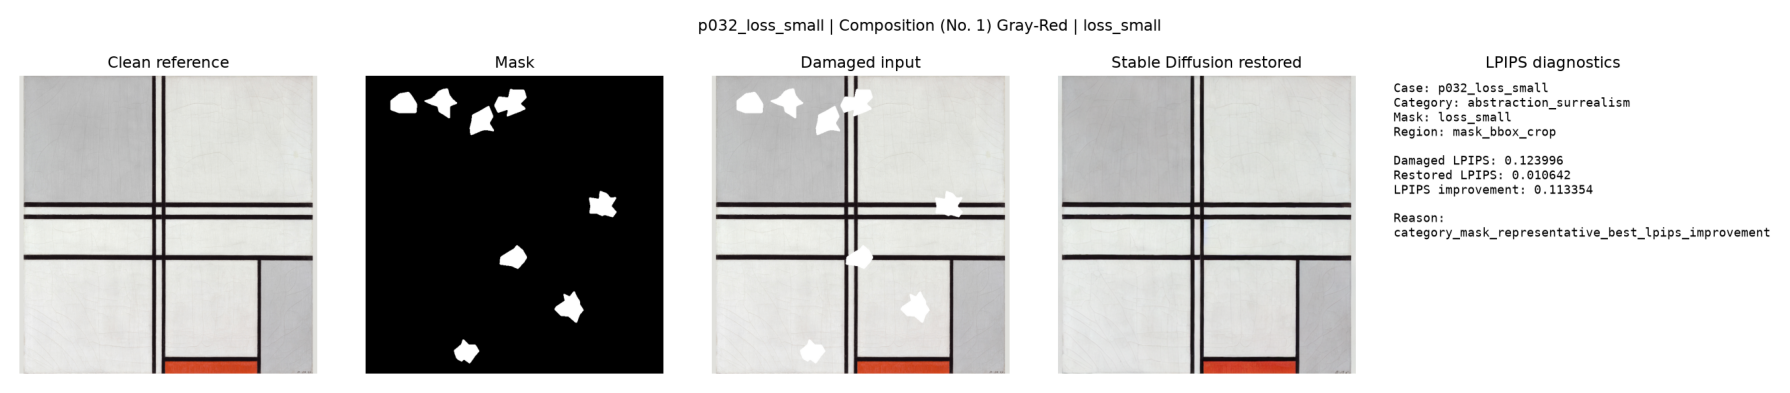

Displaying p037_loss_large | abstraction_surrealism | loss_large | category_mask_representative_best_lpips_improvement; strongest_mask_bbox_lpips_improvement


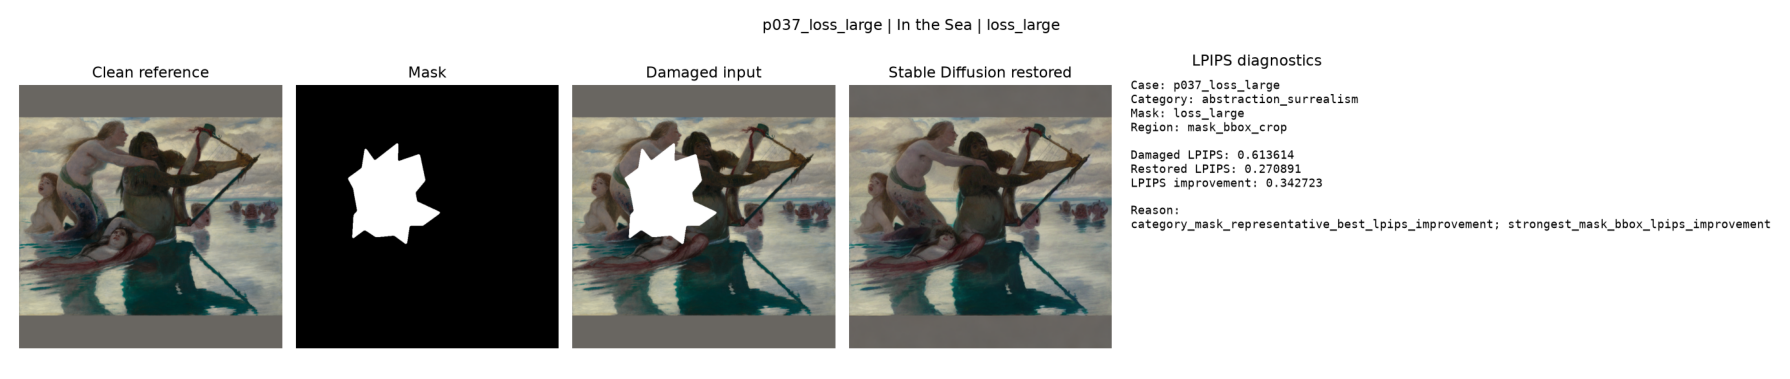

Displaying p030_scratch_thin | architecture_structured | scratch_thin | median_representative_mask_bbox_lpips_improvement


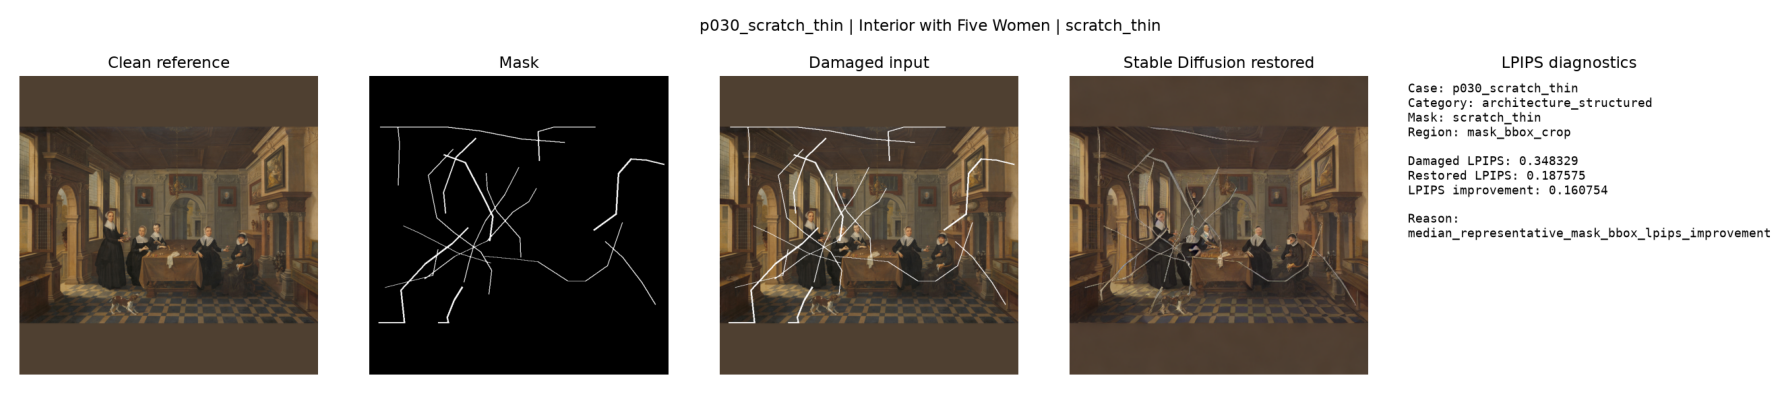

Displaying p024_loss_large | architecture_structured | loss_large | strongest_mask_bbox_lpips_improvement


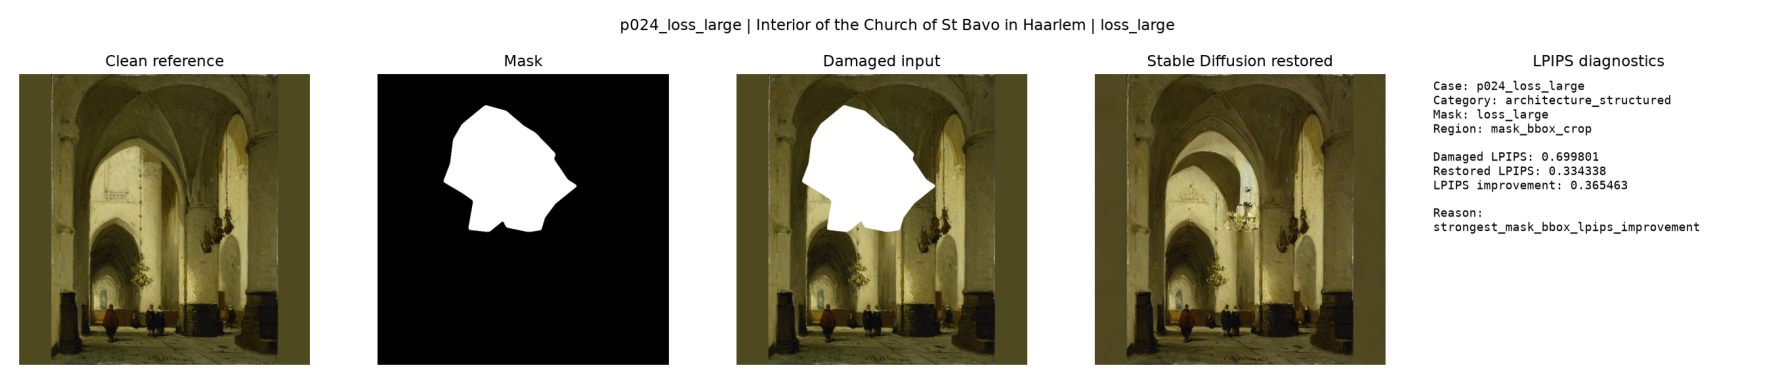

Displaying p032_scratch_thin | abstraction_surrealism | scratch_thin | weakest_mask_bbox_lpips_improvement


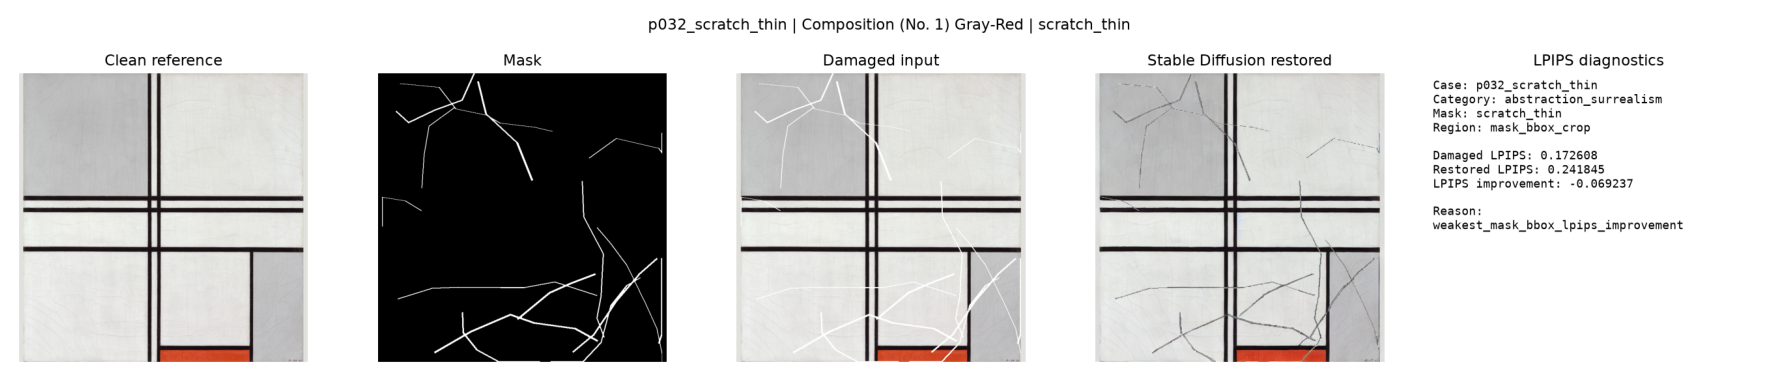

In [19]:
def display_saved_figure(path_value: str | Path) -> None:
    figure_path = Path(path_value)

    if not figure_path.exists():
        raise FileNotFoundError(f"Missing figure: {figure_path}")

    figure_img = Image.open(figure_path).convert("RGB")

    plt.figure(figsize=(18, 5))
    plt.imshow(figure_img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


sample_visual_df = (
    visual_cases_df
    .sort_values(["selection_reason", "category", "mask_type", "case_id"])
    .groupby("selection_reason", dropna=False)
    .head(1)
    .copy()
)

print("Displaying sample Stable Diffusion LPIPS visual figures:", len(sample_visual_df))

display(
    sample_visual_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reason",
            "visual_figure_path",
        ]
    ]
)

for _, row in sample_visual_df.iterrows():
    print(
        f"Displaying {row['case_id']} | "
        f"{row['category']} | {row['mask_type']} | "
        f"{row['selection_reason']}"
    )
    display_saved_figure(row["visual_figure_path"])

In [20]:
expected_lpips_files = [
    lpips_metrics_path,
    summary_by_mask_type_path,
    summary_by_category_path,
    summary_by_region_path,
    summary_by_region_mask_type_path,
    masked_region_summary_path,
    strongest_cases_path,
    weakest_cases_path,
    visual_cases_manifest_path,
]

for output_file in expected_lpips_files:
    if not output_file.exists():
        raise FileNotFoundError(
            f"Missing expected Stable Diffusion LPIPS output: {output_file}"
        )

saved_lpips_df = pd.read_csv(lpips_metrics_path)
saved_summary_by_mask_type_df = pd.read_csv(summary_by_mask_type_path)
saved_summary_by_category_df = pd.read_csv(summary_by_category_path)
saved_summary_by_region_df = pd.read_csv(summary_by_region_path)
saved_summary_by_region_mask_type_df = pd.read_csv(summary_by_region_mask_type_path)
saved_mask_bbox_summary_df = pd.read_csv(masked_region_summary_path)
saved_strongest_df = pd.read_csv(strongest_cases_path)
saved_weakest_df = pd.read_csv(weakest_cases_path)
saved_visual_cases_df = pd.read_csv(visual_cases_manifest_path)

if len(saved_lpips_df) != 700:
    raise ValueError(
        f"Expected 700 saved LPIPS rows, found {len(saved_lpips_df)}."
    )

if (saved_lpips_df["status"] != "ok").any():
    display(saved_lpips_df[saved_lpips_df["status"] != "ok"])
    raise ValueError("Saved Stable Diffusion LPIPS metrics contain non-ok rows.")

expected_region_counts = {
    "full_image": 250,
    "content_region": 250,
    "mask_bbox_crop": 200,
}

actual_region_counts = saved_lpips_df["evaluation_region"].value_counts().to_dict()

print("Expected region counts:", expected_region_counts)
print("Actual region counts:", actual_region_counts)

for region, expected_count in expected_region_counts.items():
    actual_count = actual_region_counts.get(region, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Saved LPIPS region {region!r}: expected {expected_count}, found {actual_count}."
        )

unexpected_regions = set(actual_region_counts) - set(expected_region_counts)

if unexpected_regions:
    raise ValueError(f"Unexpected LPIPS regions: {unexpected_regions}")

expected_flat_mask_counts = {
    "loss_large": 150,
    "loss_small": 150,
    "mixed_damage": 150,
    "scratch_thin": 150,
    "zero_control": 100,
}

actual_flat_mask_counts = saved_lpips_df["mask_type"].value_counts().to_dict()

print("\nExpected flat mask counts:", expected_flat_mask_counts)
print("Actual flat mask counts:", actual_flat_mask_counts)

for mask_type, expected_count in expected_flat_mask_counts.items():
    actual_count = actual_flat_mask_counts.get(mask_type, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Saved LPIPS mask type {mask_type!r}: "
            f"expected {expected_count}, found {actual_count}."
        )

expected_category_counts = {
    "portrait_figure": 140,
    "landscape_natural": 140,
    "architecture_structured": 140,
    "abstraction_surrealism": 140,
    "high_texture_brushwork": 140,
}

actual_category_counts = saved_lpips_df["category"].value_counts().to_dict()

print("\nExpected category counts:", expected_category_counts)
print("Actual category counts:", actual_category_counts)

for category, expected_count in expected_category_counts.items():
    actual_count = actual_category_counts.get(category, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Saved LPIPS category {category!r}: expected {expected_count}, found {actual_count}."
        )

if len(saved_summary_by_mask_type_df) != 5:
    raise ValueError(
        f"Expected 5 LPIPS mask-type summary rows, found {len(saved_summary_by_mask_type_df)}."
    )

if len(saved_summary_by_category_df) != 5:
    raise ValueError(
        f"Expected 5 LPIPS category summary rows, found {len(saved_summary_by_category_df)}."
    )

if len(saved_summary_by_region_df) != 3:
    raise ValueError(
        f"Expected 3 LPIPS region summary rows, found {len(saved_summary_by_region_df)}."
    )

if len(saved_mask_bbox_summary_df) != 4:
    raise ValueError(
        f"Expected 4 mask-bounding-box LPIPS summary rows, "
        f"found {len(saved_mask_bbox_summary_df)}."
    )

if len(saved_strongest_df) != 20:
    raise ValueError(
        f"Expected 20 strongest LPIPS cases, found {len(saved_strongest_df)}."
    )

if len(saved_weakest_df) != 20:
    raise ValueError(
        f"Expected 20 weakest LPIPS cases, found {len(saved_weakest_df)}."
    )

if set(saved_strongest_df["evaluation_region"].unique()) != {"mask_bbox_crop"}:
    raise ValueError("Strongest LPIPS cases should only contain mask_bbox_crop rows.")

if set(saved_weakest_df["evaluation_region"].unique()) != {"mask_bbox_crop"}:
    raise ValueError("Weakest LPIPS cases should only contain mask_bbox_crop rows.")

if len(saved_visual_cases_df) == 0:
    raise ValueError("Saved Stable Diffusion LPIPS visual cases manifest is empty.")

required_visual_columns = [
    "case_id",
    "painting_id",
    "category",
    "title",
    "mask_type",
    "evaluation_region",
    "selection_reason",
    "damaged_lpips",
    "restored_lpips",
    "lpips_improvement",
    "visual_figure_path",
]

missing_visual_columns = [
    column for column in required_visual_columns
    if column not in saved_visual_cases_df.columns
]

if missing_visual_columns:
    raise ValueError(
        f"Saved LPIPS visual manifest missing columns: {missing_visual_columns}"
    )

missing_visual_figures = [
    path
    for path in saved_visual_cases_df["visual_figure_path"]
    if str(path).strip() == "" or not Path(path).exists()
]

if missing_visual_figures:
    raise FileNotFoundError(
        f"Saved LPIPS visual manifest references missing figures: "
        f"{missing_visual_figures[:10]}"
    )

expected_selection_reasons = [
    "strongest_mask_bbox_lpips_improvement",
    "weakest_mask_bbox_lpips_improvement",
    "median_representative_mask_bbox_lpips_improvement",
    "category_mask_representative_best_lpips_improvement",
]

selection_reason_text = " ".join(
    saved_visual_cases_df["selection_reason"].fillna("").astype(str).tolist()
)

missing_selection_reasons = [
    reason
    for reason in expected_selection_reasons
    if reason not in selection_reason_text
]

if missing_selection_reasons:
    raise ValueError(
        f"Missing expected LPIPS visual selection reasons: {missing_selection_reasons}"
    )

required_metric_columns = [
    "damaged_lpips",
    "restored_lpips",
    "lpips_improvement",
]

for metric_column in required_metric_columns:
    if metric_column not in saved_lpips_df.columns:
        raise ValueError(f"Saved LPIPS metrics missing required column: {metric_column}")

print("\nSaved Stable Diffusion LPIPS metric rows:", len(saved_lpips_df))
print("Saved Stable Diffusion LPIPS visual case rows:", len(saved_visual_cases_df))
print("Final Stable Diffusion LPIPS output gates passed.")

Expected region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}
Actual region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}

Expected flat mask counts: {'loss_large': 150, 'loss_small': 150, 'mixed_damage': 150, 'scratch_thin': 150, 'zero_control': 100}
Actual flat mask counts: {'loss_large': 150, 'loss_small': 150, 'mixed_damage': 150, 'scratch_thin': 150, 'zero_control': 100}

Expected category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}
Actual category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}

Saved Stable Diffusion LPIPS metric rows: 700
Saved Stable Diffusion LPIPS visual case rows: 32
Final Stable Diffusion LPIPS output gates passed.


## Notebook 21 summary

This notebook computed LPIPS perceptual-distance metrics for the Stable Diffusion Inpainting baseline.

LPIPS was computed between:

- clean reference and damaged input,
- clean reference and Stable Diffusion restored output.

Lower LPIPS means the image is perceptually closer to the clean reference. Positive LPIPS improvement means the restoration is perceptually closer to the clean reference than the damaged input.

Evaluated regions:

- `full_image`,
- `content_region`,
- `mask_bbox_crop`.

Sparse `masked_region` pixels are not used for LPIPS because LPIPS expects image-like spatial inputs rather than unordered masked pixels. The `mask_bbox_crop` region is therefore used as the local damage-region proxy.

The final LPIPS output contains 700 rows:

- 250 full-image rows,
- 250 content-region rows,
- 200 mask-bounding-box crop rows.

Main outputs:

- `outputs/metrics/lpips_metrics_stable_diffusion_50.csv`
- `outputs/metrics/lpips_metrics_summary_by_mask_type_stable_diffusion_50.csv`
- `outputs/metrics/lpips_metrics_summary_by_category_stable_diffusion_50.csv`
- `outputs/metrics/lpips_metrics_summary_by_region_stable_diffusion_50.csv`
- `outputs/metrics/lpips_metrics_summary_by_region_mask_type_stable_diffusion_50.csv`
- `outputs/metrics/lpips_metrics_masked_region_summary_stable_diffusion_50.csv`
- `outputs/metrics/stable_diffusion_strongest_lpips_masked_region_cases_50.csv`
- `outputs/metrics/stable_diffusion_weakest_lpips_masked_region_cases_50.csv`
- `outputs/metrics/stable_diffusion_lpips_visual_cases_manifest_50.csv`
- `outputs/figures/stable_diffusion_lpips_metric_cases/`

The strongest and weakest local perceptual cases were ranked using `mask_bbox_crop` LPIPS improvement.

This stage completes the Stable Diffusion perceptual-distance layer and prepares the model for CLIP/DINOv2 feature-similarity evaluation.